In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import preprocessing
%matplotlib inline

Mounted at /content/drive


# Import

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_squared_error
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Dataset Load

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive/neuralNetwork/heart-disease-data'):
    for file in files:
        if file == 'train.csv':
            print(os.path.join(root, file))

/content/drive/MyDrive/neuralNetwork/heart-disease-data/train.csv


# Exploratory Data Analysis (EDA)

In [ ]:
df.shape

(239, 13)

In [ ]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,Outcome
0,58.0,1,400,0,40,0,164000.0,1.0,139,0,0,91,0
1,53.0,0,63,1,60,0,368000.0,0.8,135,1,0,22,0
2,75.0,0,582,0,20,1,265000.0,1.9,130,1,0,4,1
3,64.0,0,143,0,25,0,246000.0,2.4,135,1,0,214,0
4,45.0,0,582,0,20,1,126000.0,1.6,135,1,0,180,1


In [ ]:
df.sample(5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,Outcome
79,58.0,0,132,1,38,1,253000.0,1.0,139,1,0,230,0
134,55.0,0,109,0,35,0,254000.0,1.1,139,1,1,60,0
60,85.0,0,212,0,38,0,186000.0,0.9,136,1,0,187,0
98,60.0,1,76,1,25,0,196000.0,2.5,132,0,0,77,1
142,60.0,1,154,0,25,0,210000.0,1.7,135,1,0,82,1


In [ ]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,Outcome
count,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000,239.000000
mean,61.072527,0.447699,602.790795,0.447699,37.887029,0.372385,263670.546444,1.391715,136.527197,0.640167,0.317992,127.217573,0.322176
std,11.443865,0.498301,1012.362885,0.498301,11.994738,0.484455,99410.331023,1.089060,4.425657,0.480958,0.466674,77.575734,0.468291
min,40.000000,0.000000,23.000000,0.000000,15.000000,0.000000,25100.000000,0.500000,113.000000,0.000000,0.000000,4.000000,0.000000
25%,51.500000,0.000000,117.000000,0.000000,30.000000,0.000000,212500.000000,0.900000,134.000000,0.000000,0.000000,69.500000,0.000000
50%,60.000000,0.000000,253.000000,0.000000,38.000000,0.000000,263358.030000,1.100000,137.000000,1.000000,0.000000,112.000000,0.000000
75%,69.500000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.400000,139.000000,1.000000,1.000000,197.500000,1.000000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.400000,148.000000,1.000000,1.000000,280.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       239 non-null    float64
 1   anaemia                   239 non-null    int64  
 2   creatinine_phosphokinase  239 non-null    int64  
 3   diabetes                  239 non-null    int64  
 4   ejection_fraction         239 non-null    int64  
 5   high_blood_pressure       239 non-null    int64  
 6   platelets                 239 non-null    float64
 7   serum_creatinine          239 non-null    float64
 8   serum_sodium              239 non-null    int64  
 9   sex                       239 non-null    int64  
 10  smoking                   239 non-null    int64  
 11  time                      239 non-null    int64  
 12  Outcome                   239 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 24.4 KB


# Correlation analysis

In [ ]:
df.corr()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,Outcome
age,1.000000,0.065999,-0.064887,-0.120415,0.053045,0.099442,-0.054133,0.149809,-0.047133,0.087461,0.044442,-0.175326,0.196857
anaemia,0.065999,1.000000,-0.192073,-0.015293,-0.003453,0.002695,-0.059123,0.043872,0.027798,-0.096388,-0.145000,-0.141659,0.081517
creatinine_phosphokinase,-0.064887,-0.192073,1.000000,0.000303,-0.038152,-0.089529,0.032962,0.005018,0.056648,0.077155,-0.008263,-0.005222,0.090871
diabetes,-0.120415,-0.015293,0.000303,1.000000,0.025369,-0.014711,0.120718,-0.065374,-0.126528,-0.166515,-0.145000,0.007361,0.045505
ejection_fraction,0.053045,-0.003453,-0.038152,0.025369,1.000000,0.002932,0.029627,0.004087,0.169322,-0.168036,-0.100894,0.042924,-0.279239
high_blood_pressure,0.099442,0.002695,-0.089529,-0.014711,0.002932,1.000000,0.064602,-0.000101,0.056987,-0.107744,-0.079938,-0.201617,0.098647
platelets,-0.054133,-0.059123,0.032962,0.120718,0.029627,0.064602,1.000000,-0.046631,0.060487,-0.094983,0.064509,0.011983,-0.044295
serum_creatinine,0.149809,0.043872,0.005018,-0.065374,0.004087,-0.000101,-0.046631,1.000000,-0.159397,-0.012694,-0.039603,-0.157328,0.308273
serum_sodium,-0.047133,0.027798,0.056648,-0.126528,0.169322,0.056987,0.060487,-0.159397,1.000000,-0.042758,0.022242,0.099712,-0.161366
sex,0.087461,-0.096388,0.077155,-0.166515,-0.168036,-0.107744,-0.094983,-0.012694,-0.042758,1.000000,0.437058,-0.025145,0.013191


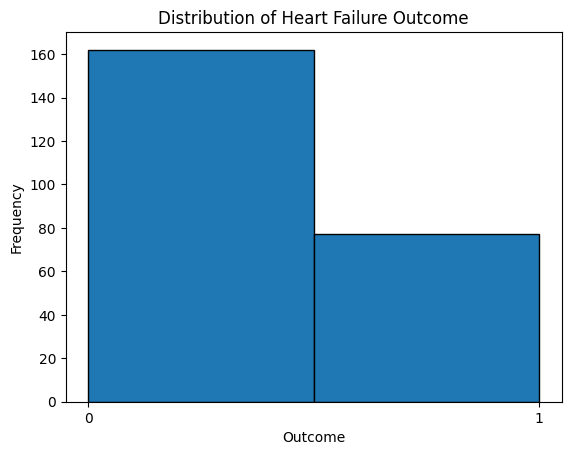

In [ ]:
import matplotlib.pyplot as plt

y = df['Outcome']

plt.hist(y, bins=2, edgecolor='black')
plt.xlabel('Outcome')
plt.ylabel('Frequency')
#plt.title('Distribution of Diabetes Outcome')
plt.title('Distribution of Heart Failure Outcome')
plt.xticks([0, 1])
plt.show()

# Dataset split into train and test data

In [ ]:
# 80% Training, 20% Testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=4,
    stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set :", X_test.shape, y_test.shape)

Training set: (191, 12) (191,)
Testing set : (48, 12) (48,)


# Linear Regression

In [ ]:

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Training Data Analysis

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_train_pred_prob = model.predict(X_train)

# Convert regression output to class 0/1
y_train_pred = (y_train_pred_prob >= 0.5).astype(int)

print("\n==============================")
print("TRAINING DATA RESULTS")
print("==============================")

print("MSE      :", mean_squared_error(y_train, y_train_pred_prob))
print("MAE      :", mean_absolute_error(y_train, y_train_pred_prob))
print("R2 Score :", r2_score(y_train, y_train_pred_prob))

print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred, zero_division=0))
print("Recall   :", recall_score(y_train, y_train_pred, zero_division=0))
print("F1 Score :", f1_score(y_train, y_train_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred, zero_division=0))


TRAINING DATA RESULTS
MSE      : 0.13055337362144862
MAE      : 0.29709195900436414
R2 Score : 0.4045114249707342
Accuracy : 0.8272251308900523
Precision: 0.7636363636363637
Recall   : 0.6774193548387096
F1 Score : 0.717948717948718

Confusion Matrix:
[[116  13]
 [ 20  42]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88       129
           1       0.76      0.68      0.72        62

    accuracy                           0.83       191
   macro avg       0.81      0.79      0.80       191
weighted avg       0.82      0.83      0.82       191




# Testing Data Analysis


In [ ]:

y_test_pred_prob = model.predict(X_test)

# Convert regression output to class 0/1
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)

print("\n==============================")
print("TESTING DATA RESULTS")
print("==============================")

print("MSE      :", mean_squared_error(y_test, y_test_pred_prob))
print("MAE      :", mean_absolute_error(y_test, y_test_pred_prob))
print("R2 Score :", r2_score(y_test, y_test_pred_prob))

print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_test_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_test_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))


TESTING DATA RESULTS
MSE      : 0.10541795899461374
MAE      : 0.2640383282753809
R2 Score : 0.5093273181341615
Accuracy : 0.9166666666666666
Precision: 0.9230769230769231
Recall   : 0.8
F1 Score : 0.8571428571428571

Confusion Matrix:
[[32  1]
 [ 3 12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        33
           1       0.92      0.80      0.86        15

    accuracy                           0.92        48
   macro avg       0.92      0.88      0.90        48
weighted avg       0.92      0.92      0.91        48



In [ ]:
import numpy as np

min_vals = np.min(X, axis=0)
max_vals = np.max(X, axis=0)

X_normalize = (X - min_vals) / (max_vals - min_vals)

print(X_normalize)

          age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0    0.327273      1.0                  0.048099       0.0           0.384615   
1    0.236364      0.0                  0.005103       1.0           0.692308   
2    0.636364      0.0                  0.071319       0.0           0.076923   
3    0.436364      0.0                  0.015310       0.0           0.153846   
4    0.090909      0.0                  0.071319       0.0           0.076923   
..        ...      ...                       ...       ...                ...   
234  0.581818      0.0                  0.023986       0.0           0.153846   
235  0.363636      1.0                  0.135111       1.0           0.461538   
236  0.163636      1.0                  0.005869       0.0           0.538462   
237  0.181818      0.0                  0.044144       1.0           0.153846   
238  0.327273      1.0                  0.004721       0.0           0.353846   

     high_blood_pressure  p

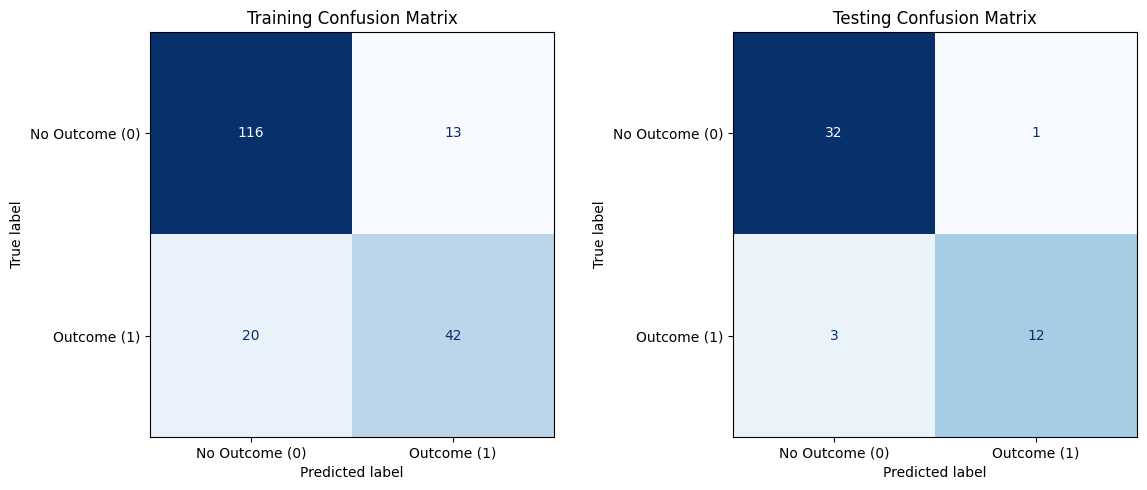

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Calculate confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

# Plot both confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=['No Outcome (0)', 'Outcome (1)']
).plot(ax=axes[0], cmap='Blues', colorbar=False)

axes[0].set_title('Training Confusion Matrix')

# Testing confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=['No Outcome (0)', 'Outcome (1)']
).plot(ax=axes[1], cmap='Blues', colorbar=False)

axes[1].set_title('Testing Confusion Matrix')

plt.tight_layout()
plt.show()

# Apply Normalization

In [ ]:
X

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,58.0,1,400,0,40,0,164000.0,1.0,139,0,0,91
1,53.0,0,63,1,60,0,368000.0,0.8,135,1,0,22
2,75.0,0,582,0,20,1,265000.0,1.9,130,1,0,4
3,64.0,0,143,0,25,0,246000.0,2.4,135,1,0,214
4,45.0,0,582,0,20,1,126000.0,1.6,135,1,0,180
...,...,...,...,...,...,...,...,...,...,...,...,...
234,72.0,0,211,0,25,0,274000.0,1.2,134,0,0,207
235,60.0,1,1082,1,45,0,250000.0,6.1,131,1,0,107
236,49.0,1,69,0,50,0,132000.0,1.0,140,0,0,147
237,50.0,0,369,1,25,0,252000.0,1.6,136,1,0,90


In [ ]:
min_vals = np.min(X, axis=0)
max_vals = np.max(X, axis=0)
normalized_X = (X - min_vals) / (max_vals - min_vals)
print(normalized_X)

          age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0    0.327273      1.0                  0.048099       0.0           0.384615   
1    0.236364      0.0                  0.005103       1.0           0.692308   
2    0.636364      0.0                  0.071319       0.0           0.076923   
3    0.436364      0.0                  0.015310       0.0           0.153846   
4    0.090909      0.0                  0.071319       0.0           0.076923   
..        ...      ...                       ...       ...                ...   
234  0.581818      0.0                  0.023986       0.0           0.153846   
235  0.363636      1.0                  0.135111       1.0           0.461538   
236  0.163636      1.0                  0.005869       0.0           0.538462   
237  0.181818      0.0                  0.044144       1.0           0.153846   
238  0.327273      1.0                  0.004721       0.0           0.353846   

     high_blood_pressure  p

===== TRAINING RESULTS =====
Accuracy : 0.8272
Precision: 0.7636
Recall   : 0.6774
F1 Score : 0.7179
MSE      : 0.1306

Classification Report:
              precision    recall  f1-score   support

  No Outcome       0.85      0.90      0.88       129
     Outcome       0.76      0.68      0.72        62

    accuracy                           0.83       191
   macro avg       0.81      0.79      0.80       191
weighted avg       0.82      0.83      0.82       191

===== TESTING RESULTS =====
Accuracy : 0.9167
Precision: 0.9231
Recall   : 0.8
F1 Score : 0.8571
MSE      : 0.1054

Classification Report:
              precision    recall  f1-score   support

  No Outcome       0.91      0.97      0.94        33
     Outcome       0.92      0.80      0.86        15

    accuracy                           0.92        48
   macro avg       0.92      0.88      0.90        48
weighted avg       0.92      0.92      0.91        48



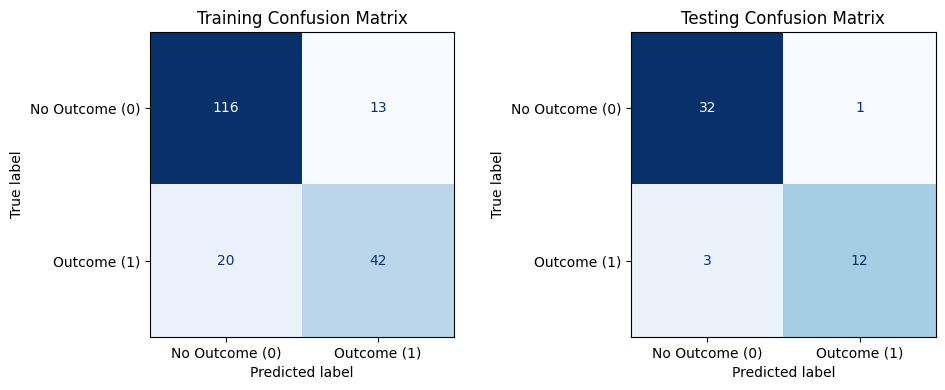

In [ ]:
# Normalize
min_vals = np.min(X, axis=0)
max_vals = np.max(X, axis=0)
X_normalize = (X - min_vals) / (max_vals - min_vals)

# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_normalize, y, test_size=0.20, random_state=4, stratify=y
)

# Train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
train_prob = model.predict(X_train)
test_prob = model.predict(X_test)

# Convert to 0 and 1
train_pred = (train_prob >= 0.5).astype(int)
test_pred = (test_prob >= 0.5).astype(int)

# =========================
# Training Results
# =========================

print("===== TRAINING RESULTS =====")

print("Accuracy :", round(accuracy_score(y_train, train_pred), 4))
print("Precision:", round(precision_score(y_train, train_pred), 4))
print("Recall   :", round(recall_score(y_train, train_pred), 4))
print("F1 Score :", round(f1_score(y_train, train_pred), 4))
print("MSE      :", round(mean_squared_error(y_train, train_prob), 4))

print("\nClassification Report:")
print(classification_report(
    y_train,
    train_pred,
    target_names=["No Outcome", "Outcome"],
    zero_division=0
))

# =========================
# Testing Results
# =========================

print("===== TESTING RESULTS =====")

print("Accuracy :", round(accuracy_score(y_test, test_pred), 4))
print("Precision:", round(precision_score(y_test, test_pred), 4))
print("Recall   :", round(recall_score(y_test, test_pred), 4))
print("F1 Score :", round(f1_score(y_test, test_pred), 4))
print("MSE      :", round(mean_squared_error(y_test, test_prob), 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    test_pred,
    target_names=["No Outcome", "Outcome"],
    zero_division=0
))

# =========================
# Confusion Matrices
# =========================

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_train, train_pred),
    display_labels=["No Outcome (0)", "Outcome (1)"]
).plot(ax=ax[0], cmap="Blues", colorbar=False)

ax[0].set_title("Training Confusion Matrix")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, test_pred),
    display_labels=["No Outcome (0)", "Outcome (1)"]
).plot(ax=ax[1], cmap="Blues", colorbar=False)

ax[1].set_title("Testing Confusion Matrix")

plt.tight_layout()
plt.show()

ORIGINAL CLASS DISTRIBUTION

Training Data:
Outcome
0    129
1     62
Name: count, dtype: int64

Testing Data:
Outcome
0    33
1    15
Name: count, dtype: int64

AFTER SMOTE
Outcome
0    129
1    129
Name: count, dtype: int64

SMOTE - TRAINING RESULTS
Accuracy : 0.814
Precision: 0.7914
Recall   : 0.8527
F1 Score : 0.8209
MSE      : 0.1414

Training Confusion Matrix:
[[100  29]
 [ 19 110]]

Training Classification Report:
              precision    recall  f1-score   support

  No Outcome       0.84      0.78      0.81       129
     Outcome       0.79      0.85      0.82       129

    accuracy                           0.81       258
   macro avg       0.82      0.81      0.81       258
weighted avg       0.82      0.81      0.81       258


SMOTE - TESTING RESULTS
Accuracy : 0.9167
Precision: 0.8667
Recall   : 0.8667
F1 Score : 0.8667
MSE      : 0.107

Testing Confusion Matrix:
[[31  2]
 [ 2 13]]

Testing Classification Report:
              precision    recall  f1-score   support

 

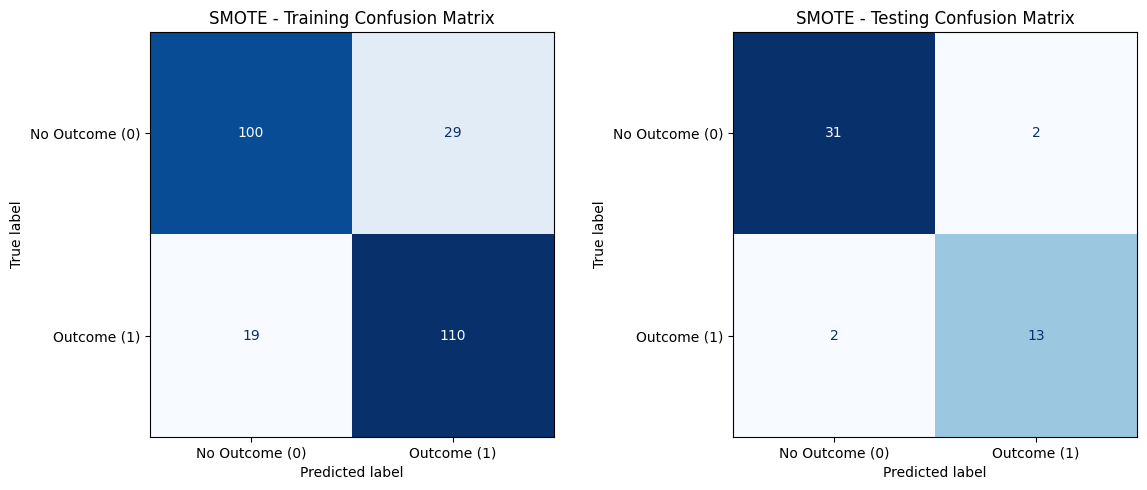


FINAL MODEL SUMMARY

Training Performance:
Accuracy : 0.814
Precision: 0.7914
Recall   : 0.8527
F1 Score : 0.8209

Testing Performance:
Accuracy : 0.9167
Precision: 0.8667
Recall   : 0.8667
F1 Score : 0.8667


In [ ]:
# ============================================================
# SMOTE + LOGISTIC REGRESSION
# Heart Failure Prediction Dataset
# Target: Outcome
# ============================================================

import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_normalize,
    y,
    test_size=0.20,
    random_state=4,
    stratify=y
)


# ============================================================
# 2. ORIGINAL CLASS DISTRIBUTION
# ============================================================

print("====================================")
print("ORIGINAL CLASS DISTRIBUTION")
print("====================================")

print("\nTraining Data:")
print(y_train.value_counts())

print("\nTesting Data:")
print(y_test.value_counts())


# ============================================================
# 3. APPLY SMOTE
# ============================================================

smote = SMOTE(random_state=4)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)


print("\n====================================")
print("AFTER SMOTE")
print("====================================")

print(y_train_smote.value_counts())


# ============================================================
# 4. TRAIN LOGISTIC REGRESSION
# ============================================================

model_smote = LogisticRegression(
    random_state=4,
    max_iter=1000
)

model_smote.fit(
    X_train_smote,
    y_train_smote
)


# ============================================================
# 5. PREDICTION
# ============================================================

# Probability prediction
train_prob = model_smote.predict_proba(
    X_train_smote
)[:, 1]

test_prob = model_smote.predict_proba(
    X_test
)[:, 1]


# Convert probability to class
train_pred = (train_prob >= 0.5).astype(int)

test_pred = (test_prob >= 0.5).astype(int)


# ============================================================
# 6. TRAINING RESULTS
# ============================================================

print("\n====================================")
print("SMOTE - TRAINING RESULTS")
print("====================================")

train_accuracy = accuracy_score(
    y_train_smote,
    train_pred
)

train_precision = precision_score(
    y_train_smote,
    train_pred,
    zero_division=0
)

train_recall = recall_score(
    y_train_smote,
    train_pred,
    zero_division=0
)

train_f1 = f1_score(
    y_train_smote,
    train_pred,
    zero_division=0
)

train_mse = mean_squared_error(
    y_train_smote,
    train_prob
)


print("Accuracy :", round(train_accuracy, 4))
print("Precision:", round(train_precision, 4))
print("Recall   :", round(train_recall, 4))
print("F1 Score :", round(train_f1, 4))
print("MSE      :", round(train_mse, 4))


# ============================================================
# 7. TRAINING CONFUSION MATRIX
# ============================================================

cm_train = confusion_matrix(
    y_train_smote,
    train_pred
)

print("\nTraining Confusion Matrix:")
print(cm_train)


# ============================================================
# 8. TRAINING CLASSIFICATION REPORT
# ============================================================

print("\nTraining Classification Report:")

print(
    classification_report(
        y_train_smote,
        train_pred,
        target_names=[
            "No Outcome",
            "Outcome"
        ],
        zero_division=0
    )
)


# ============================================================
# 9. TESTING RESULTS
# ============================================================

print("\n====================================")
print("SMOTE - TESTING RESULTS")
print("====================================")

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

test_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

test_mse = mean_squared_error(
    y_test,
    test_prob
)


print("Accuracy :", round(test_accuracy, 4))
print("Precision:", round(test_precision, 4))
print("Recall   :", round(test_recall, 4))
print("F1 Score :", round(test_f1, 4))
print("MSE      :", round(test_mse, 4))


# ============================================================
# 10. TESTING CONFUSION MATRIX
# ============================================================

cm_test = confusion_matrix(
    y_test,
    test_pred
)

print("\nTesting Confusion Matrix:")
print(cm_test)


# ============================================================
# 11. TESTING CLASSIFICATION REPORT
# ============================================================

print("\nTesting Classification Report:")

print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "No Outcome",
            "Outcome"
        ],
        zero_division=0
    )
)


# ============================================================
# 12. PLOT BOTH CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


# Training Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=[
        "No Outcome (0)",
        "Outcome (1)"
    ]
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)

axes[0].set_title(
    "SMOTE - Training Confusion Matrix"
)


# Testing Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=[
        "No Outcome (0)",
        "Outcome (1)"
    ]
).plot(
    ax=axes[1],
    cmap="Blues",
    colorbar=False
)

axes[1].set_title(
    "SMOTE - Testing Confusion Matrix"
)


plt.tight_layout()
plt.show()


# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("\n====================================")
print("FINAL MODEL SUMMARY")
print("====================================")

print("\nTraining Performance:")
print("Accuracy :", round(train_accuracy, 4))
print("Precision:", round(train_precision, 4))
print("Recall   :", round(train_recall, 4))
print("F1 Score :", round(train_f1, 4))

print("\nTesting Performance:")
print("Accuracy :", round(test_accuracy, 4))
print("Precision:", round(test_precision, 4))
print("Recall   :", round(test_recall, 4))
print("F1 Score :", round(test_f1, 4))

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import classification_report, confusion_matrix


models = {
    "Decision Tree": DecisionTreeClassifier(random_state=4),
    "SVM": SVC(random_state=4),
    "Naive Bayes": GaussianNB()
}


# ============================================
# Train and Test Models
# ============================================

for name, model in models.items():

    print("\n====================================")
    print(name)
    print("====================================")

    # Train
    model.fit(
        X_train_smote,
        y_train_smote
    )

    # Predictions
    train_pred = model.predict(X_train_smote)
    test_pred = model.predict(X_test)


    # ============================================
    # Classification Report
    # ============================================

    print("\nTesting Classification Report:")

    print(
        classification_report(
            y_test,
            test_pred,
            target_names=[
                "No Outcome",
                "Outcome"
            ],
            zero_division=0
        )
    )


    # ============================================
    # Confusion Matrix
    # ============================================

    print("Testing Confusion Matrix:")

    print(
        confusion_matrix(
            y_test,
            test_pred
        )
    )


Decision Tree

Testing Classification Report:
              precision    recall  f1-score   support

  No Outcome       0.82      0.97      0.89        33
     Outcome       0.89      0.53      0.67        15

    accuracy                           0.83        48
   macro avg       0.85      0.75      0.78        48
weighted avg       0.84      0.83      0.82        48

Testing Confusion Matrix:
[[32  1]
 [ 7  8]]

SVM

Testing Classification Report:
              precision    recall  f1-score   support

  No Outcome       0.94      0.88      0.91        33
     Outcome       0.76      0.87      0.81        15

    accuracy                           0.88        48
   macro avg       0.85      0.87      0.86        48
weighted avg       0.88      0.88      0.88        48

Testing Confusion Matrix:
[[29  4]
 [ 2 13]]

Naive Bayes

Testing Classification Report:
              precision    recall  f1-score   support

  No Outcome       0.89      0.97      0.93        33
     Outcome      

# Use Multilayer preceptron

In [ ]:
from sklearn.metrics import accuracy_score,recall_score,confusion_matrix,classification_report
import numpy as np

def sigmoid(x,lamda=1):
  return 1/(1+np.exp(-lamda*x))

# single input training
def multilayer_perceptron(I_in ,W_IH,W_HO,T,lamda,learning_rate,epoch ):
  for i in range(epoch):
    I_out = I_in                       # input-layer output
    net_H= np.dot( np.transpose(W_IH) , I_out )
    H_out = sigmoid(net_H)            # hidden-layer output

    net_O = np.dot( np.transpose(W_HO) , H_out)
    O_out = sigmoid(net_O )           # output-layer output

    del_O = lamda*O_out*(1-O_out)*(T-O_out)   # error term of Output-layer
    del_H = lamda*H_out*(1-H_out)*np.dot( W_HO,del_O ) # error term of Hidden-layer

    del_W_IH = learning_rate * np.dot( I_out , np.transpose( del_H )  ) # error term of input hidden weight
    W_IH = W_IH + del_W_IH            # input to hidden weight

    del_W_HO = learning_rate * np.dot( H_out , np.transpose( del_O )  ) # error term of hidden output weight
    W_HO = W_HO + del_W_HO            # new hidden to output weight
    #print("epoch =",i+1,"/",epoch)
  return W_IH,W_HO

# multiple input training
def multilayer_perceptron_M(X_train,y_train ,W_IH,W_HO,lamda,learning_rate,epoch ):
  # add extra column for (BIAS)
  ones_column = np.ones((X_train.shape[0], 1))
  X_train = np.c_[ones_column, X_train]

  for k in range(epoch):
    print("epoch ",k+1,"/",epoch)
    for i in range(X_train.shape[0]):
      #shape [input_layer,1]
      I_in =np.array( X_train[i]).reshape(-1, 1)
      #shape [output_layer,1]
      T = np.array(y_train[i].reshape(-1, 1))
      W_IH,W_HO=multilayer_perceptron(I_in ,W_IH,W_HO,T,lamda,learning_rate,1 )
  return W_IH,W_HO

# single prediction
def pred_(I_in,W_IH,W_HO):
  I_out = I_in
  net_H= np.dot( np.transpose(W_IH) , I_out )
  H_out = sigmoid(net_H)
  net_O = np.dot( np.transpose(W_HO) , H_out)
  O_out = sigmoid(net_O )
  return O_out

#multiple prediction
def pred_M(X,y,W_IH,W_HO):
  predict=[]
  target=[]
  # add extra column for (BIAS)
  ones_column = np.ones((X.shape[0], 1))
  X = np.c_[ones_column, X]
  for i in range(X.shape[0]):
      #shape [input_layer,1]
    I_in =np.array( X[i]).reshape(-1, 1)
      #shape [output_layer,1]
    T = np.array(y[i].reshape(-1, 1))
    pred=pred_(I_in,W_IH,W_HO)

    target.append(T)
    #print(np.floor(pred+.5).astype(int),"->",T)
    pred=np.floor(pred+.5).astype(int)
    predict.append(pred)

  return target , predict


  import matplotlib.pyplot as plt
def plot_conf(conf_matrix,title):
  plt.figure(figsize=(5, 5))
  plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
  plt.title(title)
  plt.colorbar()
  plt.xticks([0, 1], ['Predicted 0', 'Predicted 1'])
  plt.yticks([0, 1], ['Actual 0', 'Actual 1'])
  for i in range(2):
      for j in range(2):
          plt.text(j, i, str(conf_matrix[i, j]), horizontalalignment='center', color='white' if conf_matrix[i, j] > conf_matrix.max() / 2 else 'black')
  plt.xlabel('True')
  plt.ylabel('Predicted')
  plt.show()


In [ ]:
epoch = 1000
lamda=1
learning_rate=0.01
hidden_layer=10    # 5,10 ,15,20

# X_train_smote and y_train_smote are already numpy arrays from the SMOTE operation
# No need to convert them using .to_numpy() again.

#shape [input_layer+1,hidden_layer]
W_IH= np.random.rand(X_train_smote.shape[1]+1, hidden_layer)
#shape [hidden_layer,output_layer]
W_HO=  np.random.rand(hidden_layer,1)

W_IH,W_HO=multilayer_perceptron_M(X_train_smote,y_train_smote ,W_IH,W_HO,lamda,learning_rate,epoch )

print("epoch=",epoch)
print("lamda=",lamda)
print("learning_rate=",learning_rate)
print("hidden_layer=",hidden_layer)
print("input shape :",X_train.shape)
print("W_IH shape :",W_IH.shape)
print("W_HO shape :",W_HO.shape)
print("output shape :",y_train_smote.shape)

epoch  1 / 1000
epoch  2 / 1000
epoch  3 / 1000
epoch  4 / 1000
epoch  5 / 1000
epoch  6 / 1000
epoch  7 / 1000
epoch  8 / 1000
epoch  9 / 1000
epoch  10 / 1000
epoch  11 / 1000
epoch  12 / 1000
epoch  13 / 1000
epoch  14 / 1000
epoch  15 / 1000
epoch  16 / 1000
epoch  17 / 1000
epoch  18 / 1000
epoch  19 / 1000
epoch  20 / 1000
epoch  21 / 1000
epoch  22 / 1000
epoch  23 / 1000
epoch  24 / 1000
epoch  25 / 1000
epoch  26 / 1000
epoch  27 / 1000
epoch  28 / 1000
epoch  29 / 1000
epoch  30 / 1000
epoch  31 / 1000
epoch  32 / 1000
epoch  33 / 1000
epoch  34 / 1000
epoch  35 / 1000
epoch  36 / 1000
epoch  37 / 1000
epoch  38 / 1000
epoch  39 / 1000
epoch  40 / 1000
epoch  41 / 1000
epoch  42 / 1000
epoch  43 / 1000
epoch  44 / 1000
epoch  45 / 1000
epoch  46 / 1000
epoch  47 / 1000
epoch  48 / 1000
epoch  49 / 1000
epoch  50 / 1000
epoch  51 / 1000
epoch  52 / 1000
epoch  53 / 1000
epoch  54 / 1000
epoch  55 / 1000
epoch  56 / 1000
epoch  57 / 1000
epoch  58 / 1000
epoch  59 / 1000
epoch 

epoch= 1000
lamda= 1
learning_rate= 0.01
hidden_layer= 10
	Training Evalution
              precision    recall  f1-score   support

           0       0.87      0.80      0.83       129
           1       0.81      0.88      0.85       129

    accuracy                           0.84       258
   macro avg       0.84      0.84      0.84       258
weighted avg       0.84      0.84      0.84       258

[[103  26]
 [ 15 114]]


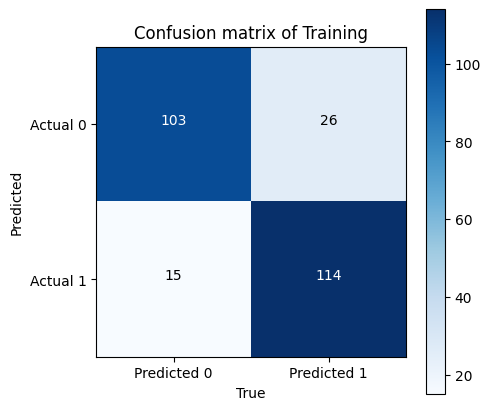

	Testing Evalution
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        33
           1       0.88      0.93      0.90        15

    accuracy                           0.94        48
   macro avg       0.92      0.94      0.93        48
weighted avg       0.94      0.94      0.94        48

[[31  2]
 [ 1 14]]


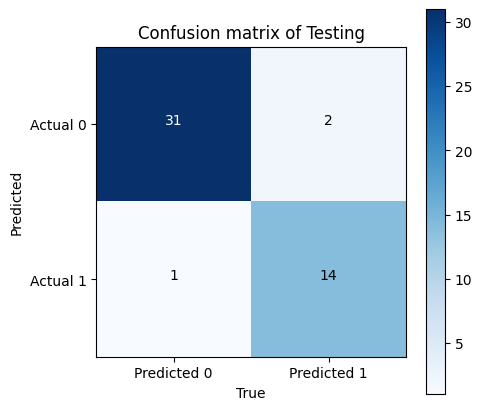

In [ ]:
target , predict = pred_M(X_train_smote,y_train_smote,W_IH,W_HO)
target=np.array(target)
predict=np.array(predict)
print("epoch=",epoch)
print("lamda=",lamda)
print("learning_rate=",learning_rate)
print("hidden_layer=",hidden_layer)
print("\tTraining Evalution")
print(classification_report(target.ravel() , predict.ravel()))
print(confusion_matrix(target.ravel() , predict.ravel()))
plot_conf(confusion_matrix(target.ravel() , predict.ravel()),"Confusion matrix of Training")

# Convert X_test and y_test to numpy arrays for consistent positional indexing in pred_M
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

target , predict = pred_M(X_test_np,y_test_np,W_IH,W_HO)
target=np.array(target)
predict=np.array(predict)
print("\tTesting Evalution")
print(classification_report(target.ravel() , predict.ravel()))
print(confusion_matrix(target.ravel() , predict.ravel()))
plot_conf(confusion_matrix(target.ravel() , predict.ravel()),"Confusion matrix of Testing")